In [2]:
import tensorflow
from tensorflow import keras 
from keras import Sequential 
from keras.layers import Dense,Flatten
from keras.applications import VGG19


In [5]:
train_folder = r"D:\DeepLearninggp\Training"
test_folder = r"D:\DeepLearninggp\Testing"


In [6]:
import os

root_folder = r"D:\DeepLearninggp\Training"
image_extensions = {".jpg", ".jpeg", ".png", ".gif", ".bmp"}  # Add more extensions if needed
total_images = 0

for foldername in os.listdir(root_folder):
    folder_path = os.path.join(root_folder, foldername)  # Correctly joining root_folder and foldername

    if os.path.isdir(folder_path):
        img_cnt = len([filename for filename in os.listdir(folder_path)
                       if os.path.splitext(filename)[1].lower() in image_extensions])
        total_images += img_cnt
        print(f"Folder '{foldername}' contains {img_cnt} image(s).")

print(f"Total images across all folders: {total_images}")


Folder 'glioma' contains 2642 image(s).
Folder 'meningioma' contains 2678 image(s).
Folder 'notumor' contains 3190 image(s).
Folder 'pituitary' contains 2914 image(s).
Total images across all folders: 11424


In [7]:
labels = ["glioma", "meningioma", "notumor", "pituitary"]


In [9]:
conv_base=VGG19(
  weights="imagenet",
  include_top=False,
  input_shape=(150,150,3)

)
conv_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

model=Sequential()
model.add(conv_base)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation="relu"))
model.add(Dense(4,activation="softmax"))

NameError: name 'Sequential' is not defined

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 4, 4, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 20,156,740 (76.89 MB)

 Non-trainable params: 0 (0.00 B)

In [2]:
conv_base.trainable=False

NameError: name 'conv_base' is not defined

In [13]:
train_ds=keras.utils.image_dataset_from_directory(
  directory=r"D:\DeepLearninggp\Training",
  labels="inferred",
  label_mode="int",
  batch_size=32,
  image_size=(150,150)
)

validation_ds=keras.utils.image_dataset_from_directory(
  directory=r"D:\DeepLearninggp\Testing",
  labels="inferred",
  batch_size=32,
  label_mode='int',
  image_size=(150,150)
)

Found 11424 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


In [14]:
def process(image,label):
    image = tensorflow.cast(image/255. ,tensorflow.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [18]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',  
    patience=4,              
    restore_best_weights=True
)

In [20]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=validation_ds,
    callbacks=[early_stopping]
)

Epoch 1/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 1011s 3s/step - accuracy: 0.8435 - loss: 0.4085 - val_accuracy: 0.8246 - val_loss: 0.4620
Epoch 2/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 1023s 3s/step - accuracy: 0.8755 - loss: 0.3293 - val_accuracy: 0.8413 - val_loss: 0.4005
Epoch 3/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 1048s 3s/step - accuracy: 0.8889 - loss: 0.2962 - val_accuracy: 0.8696 - val_loss: 0.3626
Epoch 4/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 944s 3s/step - accuracy: 0.9027 - loss: 0.2626 - val_accuracy: 0.8673 - val_loss: 0.3586
Epoch 5/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 658s 2s/step - accuracy: 0.9112 - loss: 0.2469 - val_accuracy: 0.8757 - val_loss: 0.3338
Epoch 6/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 605s 2s/step - accuracy: 0.9166 - loss: 0.2286 - val_accuracy: 0.8368 - val_loss: 0.4104
Epoch 7/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.9181 - loss: 0.2108 - val_accuracy: 0.8863 - val_loss: 0.2790
Epoch 8/50
357/357 ━━━━━━━━━━━━━━━━━━━━ 766s 2s/step - accuracy: 0.9278 - loss: 0.1999 - val_a

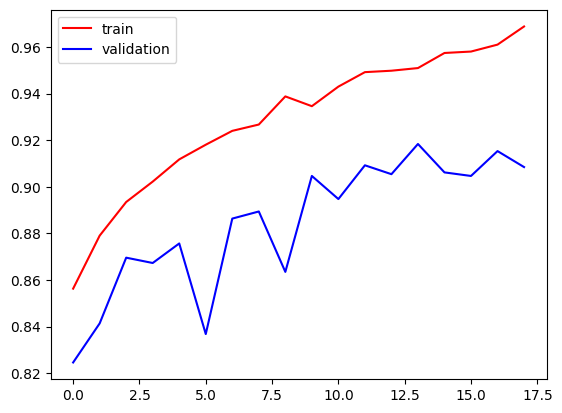

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [3]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

NameError: name 'plt' is not defined

41/41 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step
Confusion Matrix:
[[ 52  84  92  72]
 [ 51  82 106  67]
 [ 91 103 124  87]
 [ 60  81  91  68]]


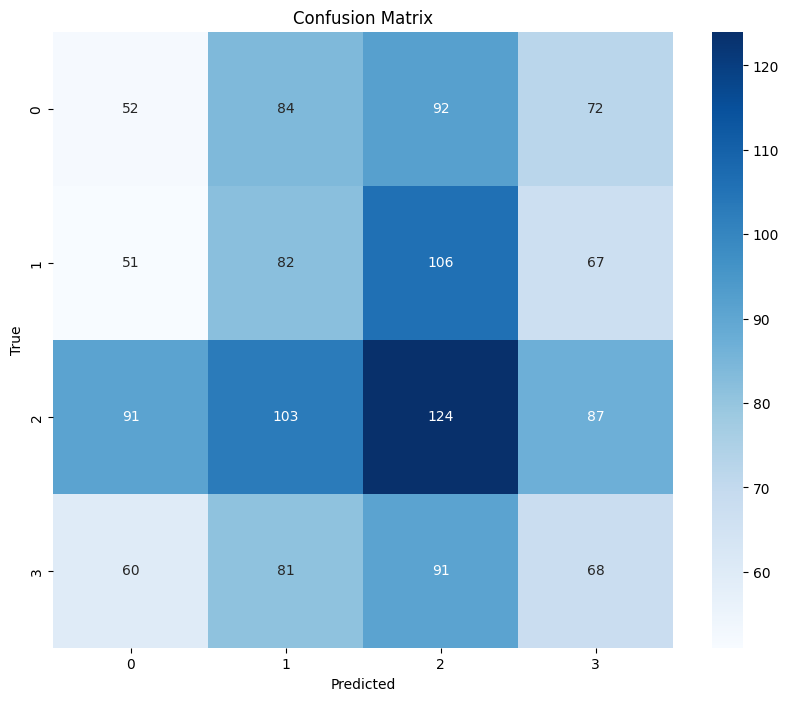


Classification Report:
              precision    recall  f1-score   support

      Glioma       0.20      0.17      0.19       300
  Meningioma       0.23      0.27      0.25       306
   Pituitary       0.30      0.31      0.30       405
    No_Tumor       0.23      0.23      0.23       300

    accuracy                           0.25      1311
   macro avg       0.24      0.24      0.24      1311
weighted avg       0.25      0.25      0.25      1311



In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = np.argmax(model.predict(validation_ds), axis=-1)
y_true = np.concatenate([y for _, y in validation_ds], axis=0)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Print Confusion Matrix
print("Confusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Generate and print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Glioma', 'Meningioma', 'Pituitary', 'No_Tumor']))


In [26]:
model.save('vgg-19.h5')